## The idea here is to visualize the output of the data preprocessing step in the implementation of ViT.

In [1]:
from ai4wc.data_processing.preprocess import read_image, resize_image, image_to_patches, flatten_patches, flatten_patch, stack_patches, create_embedding_matrix, project_patches, add_cls_token, add_positional_embeddings
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

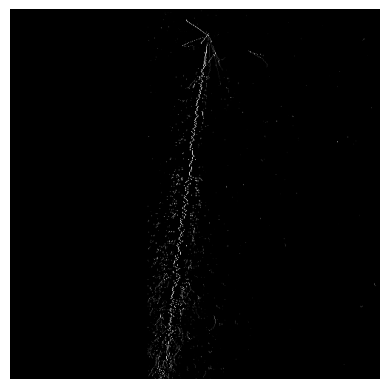

In [11]:
# read image named event.png
img = resize_image(image=read_image('event.png'), target_size=500)
# plot image
plt.imshow(img)
plt.axis("off")
plt.show()

In [12]:
def visualize_preprocessed_image(PIL_img, preprocess_fn, figsize=(10, 10)):
    preprocessed_img = preprocess_fn(PIL_img)
    print(f'shape of preprocessed image: {preprocessed_img.shape}')
    # Convert tensor to numpy array and transpose dimensions for plotting
    # the shape is (num_patches, patch_size, patch_size, channels)
    num_patches = preprocessed_img.shape[0]
    patch_size = preprocessed_img.shape[1]
    grid_size = int(np.ceil(np.sqrt(num_patches)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=figsize)
    for i in range(grid_size * grid_size):
        ax = axes[i // grid_size, i % grid_size]
        if i < num_patches:
            patch = preprocessed_img[i]
            ax.imshow(patch)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

shape of preprocessed image: (100, 50, 50, 4)


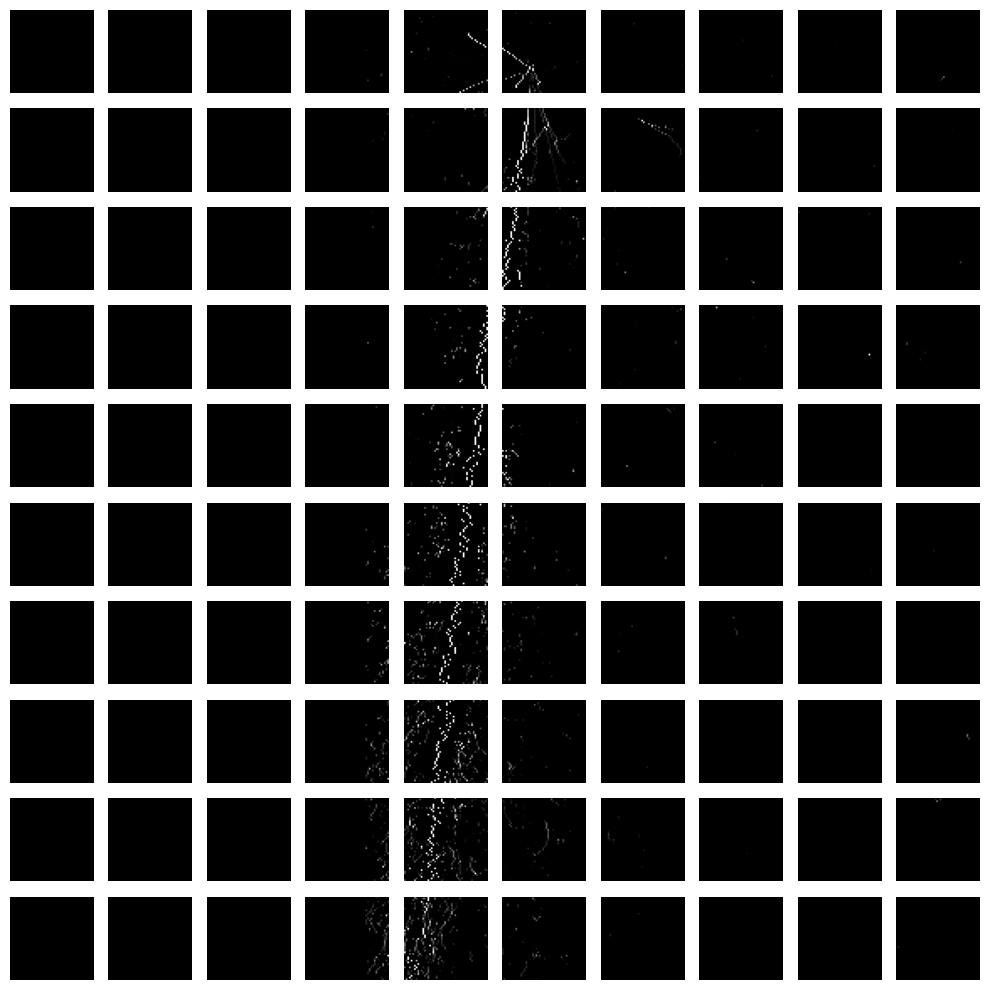

In [17]:
# image to patches
patches = image_to_patches(img, patch_size=50)
visualize_preprocessed_image(img, lambda x: image_to_patches(resize_image(x, target_size=500), patch_size=50))

In [20]:
flatten_patches_vec = flatten_patches(patches=image_to_patches(resize_image(img, target_size=500), patch_size=50))
print(f'shape of flattened patches: {flatten_patch.shape}')

shape of flattened patches: (100, 10000)


In [21]:
flatten_patches_vec

array([[  0,   0,   0, ...,   0,   0, 255],
       [  0,   0,   0, ...,   0,   0, 255],
       [  0,   0,   0, ...,   0,   0, 255],
       ...,
       [  0,   0,   0, ...,   0,   0, 255],
       [  0,   0,   0, ...,   0,   0, 255],
       [  0,   0,   0, ...,   0,   0, 255]], dtype=uint8)

In [26]:
stack_patch_vec = stack_patches(patch_vectors=flatten_patches_vec)

In [28]:
stack_patch_vec

array([[  0,   0,   0, ...,   0,   0, 255],
       [  0,   0,   0, ...,   0,   0, 255],
       [  0,   0,   0, ...,   0,   0, 255],
       ...,
       [  0,   0,   0, ...,   0,   0, 255],
       [  0,   0,   0, ...,   0,   0, 255],
       [  0,   0,   0, ...,   0,   0, 255]], dtype=uint8)

In [46]:
matrix_embedding = create_embedding_matrix(patch_vector_size=stack_patch_vec.shape[1], embedding_dim=stack_patch_vec.shape[0])

In [62]:
stack_patch_vec.shape

(100, 10000)

In [48]:
matrix_embedding.shape

(10000, 100)

In [49]:
prject_patches = project_patches(patch_vectors=stack_patch_vec, embedding_matrix=matrix_embedding)

In [57]:
prject_patches.shape

(100, 100)

In [52]:
print(prject_patches)

[[-135.1712915   269.17722326  -72.70674412 ...  187.13303092
   -31.91709043    3.14680595]
 [-135.1712915   269.17722326  -72.70674412 ...  187.13303092
   -31.91709043    3.14680595]
 [-135.1712915   269.17722326  -72.70674412 ...  187.13303092
   -31.91709043    3.14680595]
 ...
 [-135.1712915   269.17722326  -72.70674412 ...  187.13303092
   -31.91709043    3.14680595]
 [-135.1712915   269.17722326  -72.70674412 ...  187.13303092
   -31.91709043    3.14680595]
 [-134.926325    268.99536577  -73.57861652 ...  187.44972555
   -32.43396963    3.22807613]]


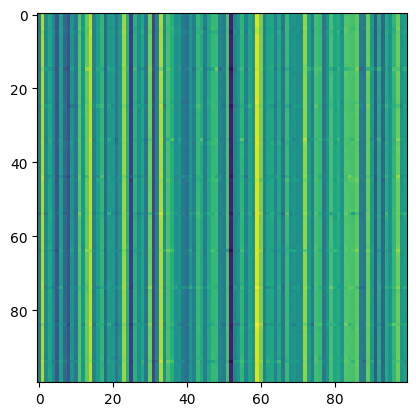

In [61]:
plt.imshow(prject_patches.reshape(100, 100, 1))